# Understanding what drives dissatisfaction and building the core story (Main Story)

### Business questions

1. What factors in the customer journey (including acquisition channel and delivery performance) drive customer dissatisfaction?

2. How does dissatisfaction impact customer behavior, particularly repeat purchase?

3. Can we predict which orders are at risk of dissatisfaction based on known features?

4. How do acquisition channels shape expectations and influence downstream customer experience?



### Table of Contents (Charts)

- Chart 1: dissatisfaction rate
- Chart 2: delivery delay distribution
- Chart 3: delay vs dissatisfaction
- Chart 4: monthly dissatisfaction
- Chart 5: repeat vs non-repeat
- Chart 6: review score distribution
- Chart 7: probability of a written review based on score
- Chart 8: dissatisfaction by order value
- Chart 9: dissastifaction by delay bucket
- Chart 11: dissatisfaction risk concentration

In [55]:
import pandas as pd
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

processed_path = Path("../") / config["paths"]["processed_data"]
file_name = config["files"]["main_dataset"]
df = pd.read_csv("../data/processed/main_dataset.csv")

In [56]:
import sys
sys.path.append("..")  # adjust if needed

from utils import *

In [57]:
# Time features
df["purchase_month"] = pd.to_datetime(df["order_purchase_timestamp"]).dt.month
df["purchase_dayofweek"] = pd.to_datetime(df["order_purchase_timestamp"]).dt.dayofweek
df["purchase_hour"] = pd.to_datetime(df["order_purchase_timestamp"]).dt.hour

In [80]:
# Creating order value bands
df["order_value_band"] = pd.qcut(df["order_value"], q=4, labels=["Low", "Mid-Low", "Mid-High", "High"])

In [59]:
customer_orders = df.groupby("customer_unique_id")["order_id"].count()
repeat_customers = customer_orders[customer_orders > 1].index

df["is_repeat_customer"] = df["customer_unique_id"].isin(repeat_customers).astype(int)

In [60]:
date_cols = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

In [61]:
df["delivery_delay"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.days

In [62]:
df["is_dissatisfied"] = df["review_score"].apply(lambda x: 1 if x <= 2 else 0)

### 1. Understanding the target

In [35]:
# What is dissatisfaction?
df["is_dissatisfied"].value_counts(normalize=True)*100

is_dissatisfied
0    87.183346
1    12.816654
Name: proportion, dtype: float64

Dissatisfaction affects ~13% of orders, making it a meaningful but minority outcome.

In [53]:
# Dissatisfaction by order value
value_diss = (
    df.groupby("order_value_band")["is_dissatisfied"]
    .mean()
    * 100
)

/var/folders/0_/937qdrnn19vgx61scsk5r5j40000gn/T/ipykernel_61274/1216265082.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("order_value_band")["is_dissatisfied"]


### 2. Core driver: delivery delays

In [36]:
df["delivery_delay"].describe()

count    96359.000000
mean       -11.917797
std         10.114024
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay, dtype: float64

### 3. Customer behavior layer

In [37]:
# Check repeat customers and create a flag for them
df["customer_unique_id"].nunique()

92753

In [38]:
customer_orders = df.groupby("customer_unique_id")["order_id"].count()

repeat_customers = customer_orders[customer_orders > 1].index

df["is_repeat_customer"] = df["customer_unique_id"].isin(repeat_customers).astype(int)

In [39]:
# Compare dissatisfaction rates between repeat and non-repeat customers
df.groupby("is_repeat_customer")["is_dissatisfied"].mean()*100

is_repeat_customer
0    12.864437
1    12.151703
Name: is_dissatisfied, dtype: float64

Repeat customers show slightly lower dissatisfaction rates.

In [40]:
# Quick fix for all dates that before were strings and not datetime objects
date_cols = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

In [41]:
df["purchase_month"] = df["order_purchase_timestamp"].dt.month
df["purchase_month_name"] = df["order_purchase_timestamp"].dt.strftime("%b")
df["purchase_dayofweek"] = df["order_purchase_timestamp"].dt.dayofweek
df["purchase_hour"] = df["order_purchase_timestamp"].dt.hour

### Chart 1 — dissatisfaction rate

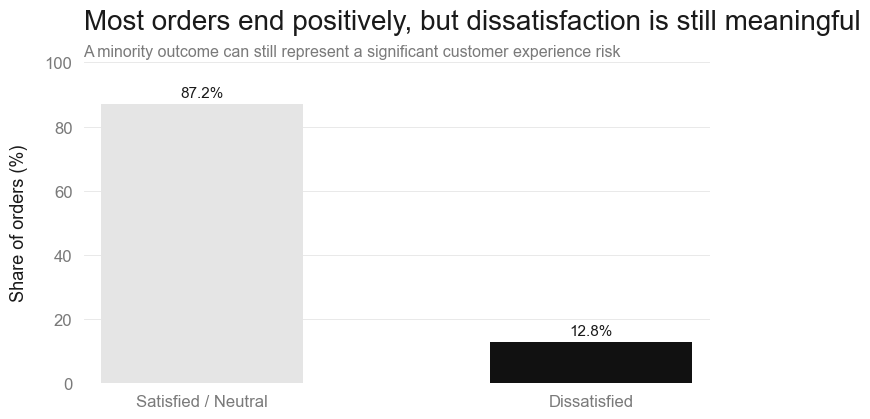

In [42]:
dissatisfaction_rate = df["is_dissatisfied"].mean() * 100

fig, ax = create_figure(figsize=(8, 5))

labels = ["Satisfied / Neutral", "Dissatisfied"]
values = [100 - dissatisfaction_rate, dissatisfaction_rate]
colors = [LIGHT, ACCENT]

bars = ax.bar(labels, values, color=colors, width=0.52)

add_title(
    ax,
    "Most orders end positively, but dissatisfaction is still meaningful",
    "A minority outcome can still represent a significant customer experience risk"
)

ax.set_ylabel("Share of orders (%)")
ax.set_ylim(0, 100)
clean_axes(ax, grid_axis="y")

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 1.2,
        f"{h:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        color=DARK
    )

plt.tight_layout(pad=3)
plt.show()
save_fig(fig, "01_dissatisfaction_rate_boss_style.png")

### Chart 2 — delivery delay distribution

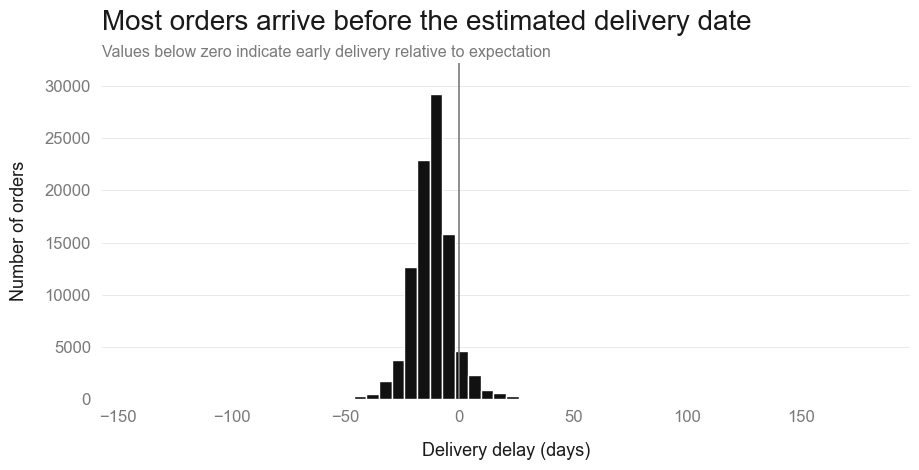

In [43]:
fig, ax = create_figure(figsize=(10, 5.5))

ax.hist(df["delivery_delay"].dropna(), bins=60, color=ACCENT, edgecolor=BG)
ax.axvline(0, color=MID, linewidth=1.2)

add_title(
    ax,
    "Most orders arrive before the estimated delivery date",
    "Values below zero indicate early delivery relative to expectation"
)

ax.set_xlabel("Delivery delay (days)")
ax.set_ylabel("Number of orders")
clean_axes(ax, grid_axis="y")

plt.tight_layout(pad=3)
plt.show()
save_fig(fig, "02_delivery_delay_distribution_boss_style.png")

### Chart 3 — average delivery delay vs dissatisfaction

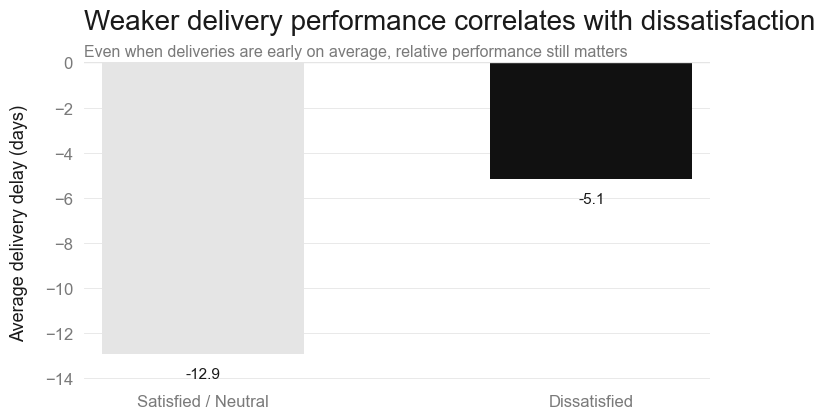

In [44]:
delay_by_group = (
    df.groupby("is_dissatisfied")["delivery_delay"]
    .mean()
    .rename(index={0: "Satisfied / Neutral", 1: "Dissatisfied"})
)

fig, ax = create_figure(figsize=(8, 5))

bars = ax.bar(
    delay_by_group.index,
    delay_by_group.values,
    color=[LIGHT, ACCENT],
    width=0.52
)

ax.axhline(0, color=LIGHT, linewidth=1)

add_title(
    ax,
    "Weaker delivery performance correlates with dissatisfaction",
    "Even when deliveries are early on average, relative performance still matters"
)

ax.set_ylabel("Average delivery delay (days)")
clean_axes(ax, grid_axis="y")

for bar in bars:
    h = bar.get_height()
    offset = 0.4 if h >= 0 else -0.6
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + offset,
        f"{h:.1f}",
        ha="center",
        va="bottom" if h >= 0 else "top",
        fontsize=11,
        color=DARK
    )

plt.tight_layout(pad=3)
plt.show()
save_fig(fig, "03_delay_vs_dissatisfaction_boss_style.png")

Even though both groups received their orders earlier than expected, dissatisfied customers experienced significantly less early delivery on average. This suggests that customer perception is shaped not just by whether a delivery is late, but by how strongly it exceeds expectations.

Customers seem to reward overperformance, not just acceptable performance.

### Chart 4 — dissatisfaction by month

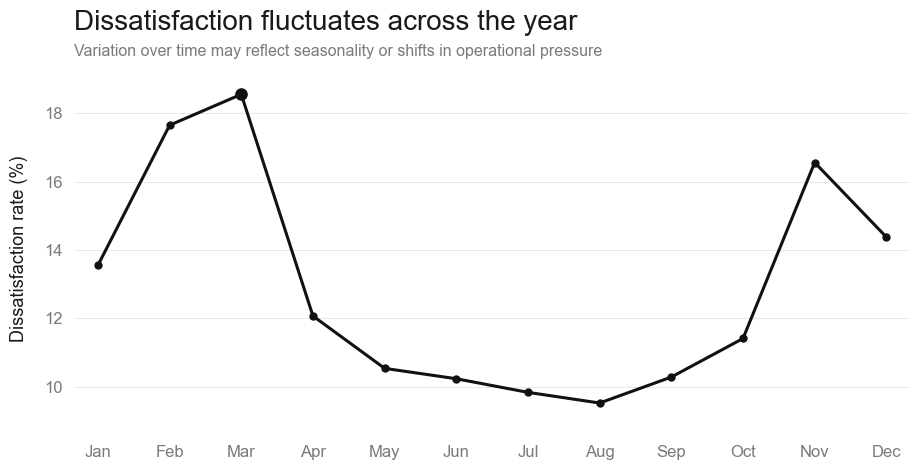

In [45]:
monthly = (
    df.groupby(["purchase_month", "purchase_month_name"])["is_dissatisfied"]
    .mean()
    .reset_index()
    .sort_values("purchase_month")
)

fig, ax = create_figure(figsize=(10, 5.5))

x = monthly["purchase_month_name"]
y = monthly["is_dissatisfied"] * 100

ax.plot(x, y, color=ACCENT, linewidth=2.2, marker="o", markersize=5)

peak_idx = y.idxmax()
ax.scatter(x.iloc[peak_idx], y.iloc[peak_idx], color=ACCENT, s=65, zorder=3)

add_title(
    ax,
    "Dissatisfaction fluctuates across the year",
    "Variation over time may reflect seasonality or shifts in operational pressure"
)

ax.set_ylabel("Dissatisfaction rate (%)")
clean_axes(ax, grid_axis="y")

plt.tight_layout(pad=3)
plt.show()
save_fig(fig, "04_dissatisfaction_by_month_boss_style.png")

### Chart 5 — repeat vs non-repeat customers

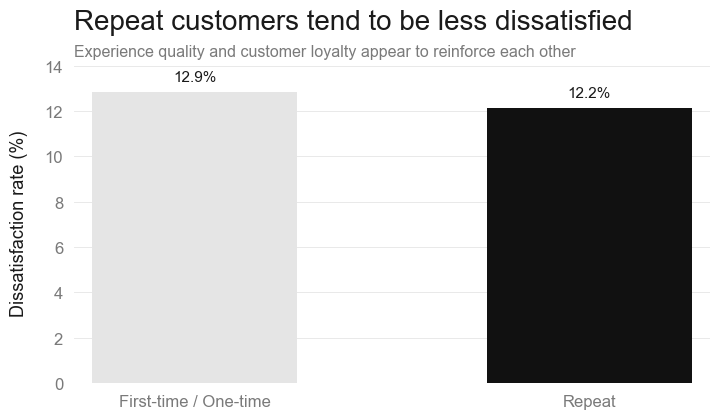

In [46]:
repeat_rates = (
    df.groupby("is_repeat_customer")["is_dissatisfied"]
    .mean()
    .rename(index={0: "First-time / One-time", 1: "Repeat"})
    * 100
)

fig, ax = create_figure(figsize=(8, 5))

bars = ax.bar(
    repeat_rates.index,
    repeat_rates.values,
    color=[LIGHT, ACCENT],
    width=0.52
)

add_title(
    ax,
    "Repeat customers tend to be less dissatisfied",
    "Experience quality and customer loyalty appear to reinforce each other"
)

ax.set_ylabel("Dissatisfaction rate (%)")
clean_axes(ax, grid_axis="y")

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.35,
        f"{h:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        color=DARK
    )

plt.tight_layout(pad=3)
plt.show()
save_fig(fig, "05_repeat_customer_dissatisfaction_boss_style.png")

### Chart 6 — review score distribution

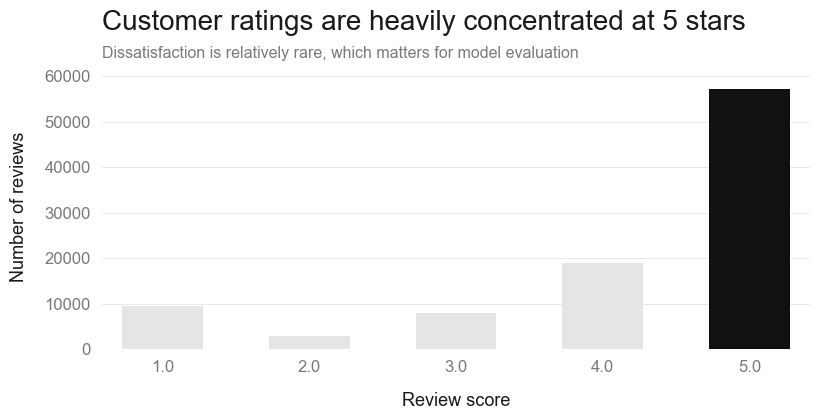

In [47]:
review_dist = df["review_score"].value_counts().sort_index()

fig, ax = create_figure(figsize=(9, 5))

bar_colors = [LIGHT, LIGHT, LIGHT, LIGHT, ACCENT]
bars = ax.bar(review_dist.index.astype(str), review_dist.values, color=bar_colors, width=0.55)

add_title(
    ax,
    "Customer ratings are heavily concentrated at 5 stars",
    "Dissatisfaction is relatively rare, which matters for model evaluation"
)

ax.set_xlabel("Review score")
ax.set_ylabel("Number of reviews")
clean_axes(ax, grid_axis="y")

plt.tight_layout(pad=3)
plt.show()
save_fig(fig, "06_review_score_distribution_boss_style.png")

Most customers are happy → dissatisfaction sends is a strong signal when it happens

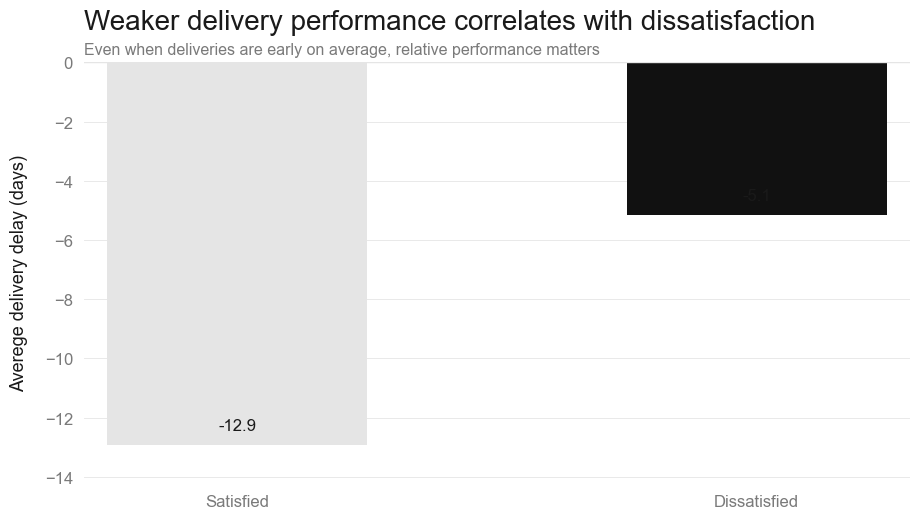

In [66]:
fig, ax = create_figure()

delay_by_group = (
    df.groupby("is_dissatisfied")["delivery_delay"]
    .mean()
    .rename(index={0: "Satisfied", 1: "Dissatisfied"})
)

colors = [LIGHT, ACCENT]

bars = ax.bar(delay_by_group.index, delay_by_group.values, color=colors, width=0.5)

ax.axhline(0, color=LIGHT, linewidth=1)

add_title(
    ax,
    "Weaker delivery performance correlates with dissatisfaction",
    "Even when deliveries are early on average, relative performance matters"
)

clean_axes(ax)
ax.set_ylabel("Averege delivery delay (days)")

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.4,
        f"{h:.1f}",
        ha="center",
        va="bottom",
        fontsize=12,
        color=DARK
    )

plt.tight_layout(pad=3)
plt.show()

- Negative value → delivered before expected
- Positive value → delivered after expected

Even though both groups received their orders earlier than expected, dissatisfied customers experienced significantly less early delivery on average. This suggests that customer perception is shaped not just by whether a delivery is late, but by how strongly it exceeds expectations.

“Expectation gap” matters more than absolute timing.

### Core Insights:

1. Delivery performance drives dissatisfaction
2. Dissatisfaction is a minority but impactful outcome
3. Repeat customers behave differently
4. Timing/seasonality affects experience

Customer dissatisfaction is strongly linked to delivery performance and customer context, suggesting that experience gaps are driven by operational execution rather than random behavior.

### Additional Questions:

Does the likelihood of leaving a written review depend on the review score?

In [49]:
df["has_written_review"] = (
    df["review_comment_message"].notna() | 
    df["review_comment_title"].notna()
).astype(int)

In [50]:
# Group by review score
review_text_rate = (
    df.groupby("review_score")["has_written_review"]
    .mean()
    * 100
)

### Chart 7 - probability of a written review based on score

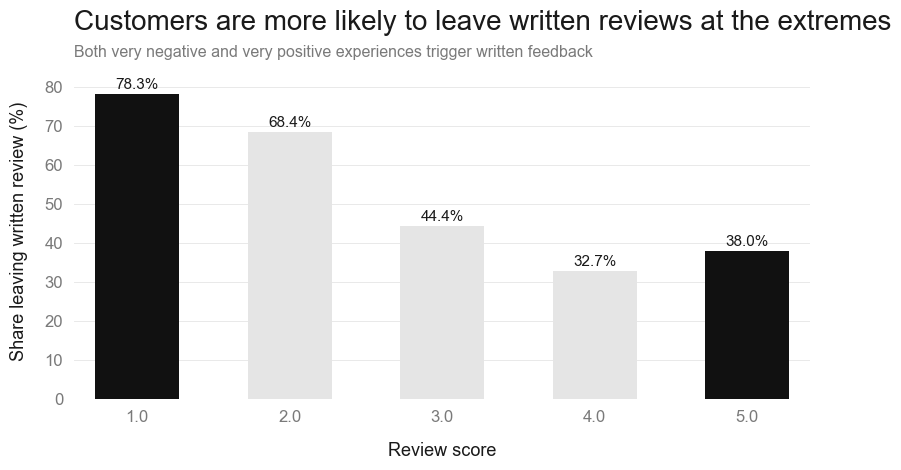

In [51]:
fig, ax = create_figure(figsize=(9, 5.5))

x = review_text_rate.index.astype(str)
y = review_text_rate.values

# Highlight extremes (1-star and 5-star)
colors = [
    ACCENT if score in [1, 5] else LIGHT 
    for score in review_text_rate.index
]

bars = ax.bar(x, y, color=colors, width=0.55)

add_title(
    ax,
    "Customers are more likely to leave written reviews at the extremes",
    "Both very negative and very positive experiences trigger written feedback"
)

ax.set_xlabel("Review score")
ax.set_ylabel("Share leaving written review (%)")

clean_axes(ax, grid_axis="y")

# Add labels
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.6,
        f"{h:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        color=DARK
    )

plt.tight_layout(pad=3)
plt.show()

save_fig(fig, "07_written_review_by_score.png")

In [52]:
df.to_csv("../data/processed/main_dataset.csv", index=False)

### Chart 8 - dissatisfaction by order value

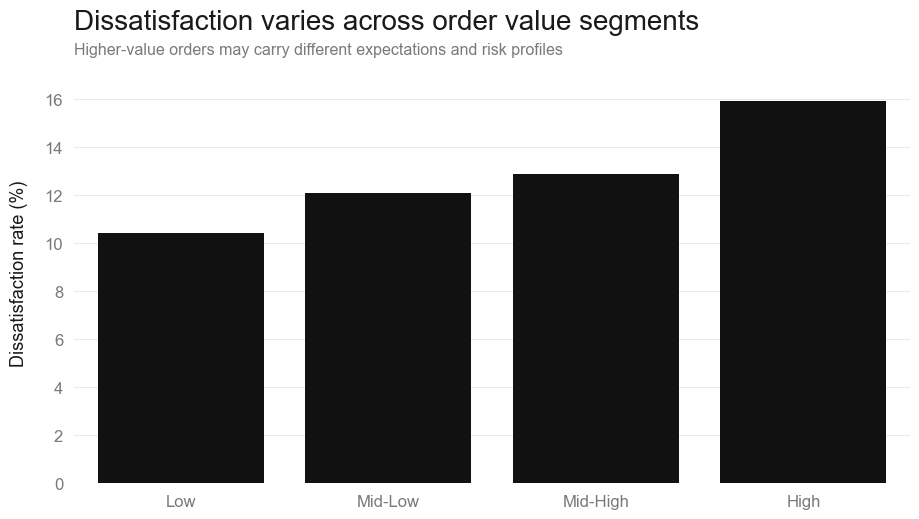

In [68]:
fig, ax = create_figure()

bars = ax.bar(value_diss.index, value_diss.values, color=ACCENT)

add_title(
    ax,
    "Dissatisfaction varies across order value segments",
    "Higher-value orders may carry different expectations and risk profiles"
)

ax.set_ylabel("Dissatisfaction rate (%)")

clean_axes(ax)

plt.tight_layout(pad=3)
plt.show()

save_fig(fig, "08_transaction_value_customer_expectation.png")

Higher-value orders show slightly different dissatisfaction patterns, suggesting that customer expectations may scale with transaction value.

In [63]:
df["delay_bucket"] = pd.cut(
    df["delivery_delay"],
    bins=[-30, -3, 0, 3, 30],
    labels=["Very Early", "Slightly Early", "On Time", "Late"]
)

In [64]:
delay_diss = (
    df.groupby("delay_bucket")["is_dissatisfied"]
    .mean()
    * 100
)

/var/folders/0_/937qdrnn19vgx61scsk5r5j40000gn/T/ipykernel_61274/1218829522.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("delay_bucket")["is_dissatisfied"]


### Chart 9 - dissastifaction by delay bucket

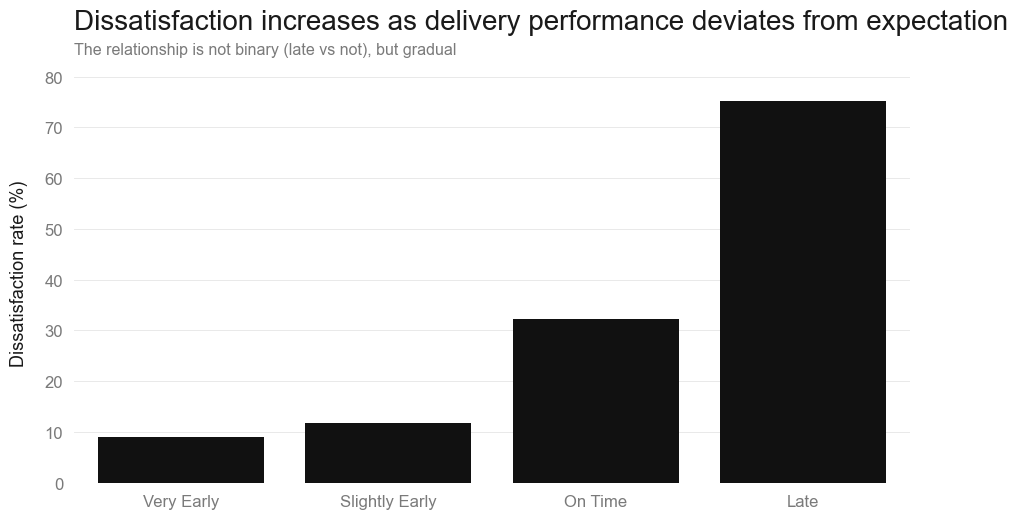

In [69]:
fig, ax = create_figure()

bars = ax.bar(delay_diss.index.astype(str), delay_diss.values, color=ACCENT)

add_title(
    ax,
    "Dissatisfaction increases as delivery performance deviates from expectation",
    "The relationship is not binary (late vs not), but gradual"
)

ax.set_ylabel("Dissatisfaction rate (%)")

clean_axes(ax)

plt.tight_layout(pad=3)
plt.show()

save_fig(fig, "09_dissatisfaction_delivery_performance.png")

Customer dissatisfaction increases progressively as delivery performance worsens relative to expectations, suggesting that perception is shaped by deviation rather than a simple late/on-time binary.

In [ ]:
#df.to_csv("../data/processed/main_dataset.csv", index=False)

### Action: Identifying High-Risk Orders

In [71]:
df["risk_segment"] = pd.cut(
    df["delivery_delay"],
    bins=[-30, -3, 0, 3, 30],
    labels=["Very Early", "Slightly Early", "On Time", "Late"]
)

In [72]:
df["value_segment"] = pd.qcut(
    df["order_value"], 
    q=3, 
    labels=["Low Value", "Mid Value", "High Value"]
)

In [74]:
risk_matrix = (
    df.groupby(["risk_segment", "value_segment"])["is_dissatisfied"]
    .mean()
    .unstack()
    * 100
)

risk_matrix

/var/folders/0_/937qdrnn19vgx61scsk5r5j40000gn/T/ipykernel_61274/3494982989.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["risk_segment", "value_segment"])["is_dissatisfied"]


value_segment,Low Value,Mid Value,High Value
risk_segment,,,
Very Early,7.516970,8.568232,11.281731
Slightly Early,10.146777,11.243851,14.165391
On Time,28.119800,36.523126,31.687898
Late,75.468484,74.061196,76.163873


Late deliveries are the single most critical failure point in the customer journey - regardless of order value.

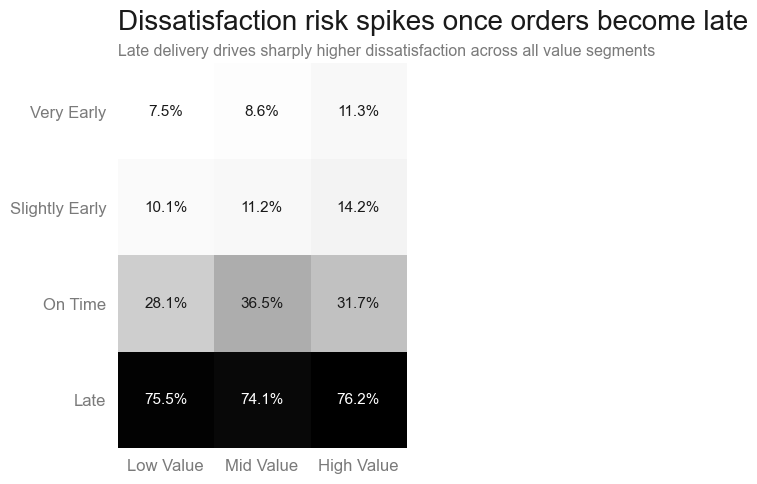

In [79]:
fig, ax = create_figure(figsize=(8, 5))

im = ax.imshow(risk_matrix, cmap="Greys")

ax.set_xticks(range(len(risk_matrix.columns)))
ax.set_yticks(range(len(risk_matrix.index)))
ax.set_xticklabels(risk_matrix.columns)
ax.set_yticklabels(risk_matrix.index)

add_title(
    ax,
    "Dissatisfaction risk spikes once orders become late",
    "Late delivery drives sharply higher dissatisfaction across all value segments"
)

clean_axes(ax, grid_axis="both")
ax.grid(False)

for i in range(risk_matrix.shape[0]):
    for j in range(risk_matrix.shape[1]):
        value = risk_matrix.iloc[i, j]
        ax.text(
            j, i, f"{value:.1f}%",
            ha="center", va="center",
            color="white" if value > 40 else DARK,
            fontsize=11
        )

plt.tight_layout()
plt.show()

save_fig(fig, "11_dissatisfaction_risk_concentration.png")

The main takeaway is not that high-value orders are uniquely fragile, but that late delivery is the dominant failure point regardless of order value. Preventing lateness is therefore the single highest-impact operational lever for reducing dissatisfaction.